In [11]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from pathlib import Path

TITLE_SIZE = 18
LABEL_SIZE = 14
TICK_SIZE = 12




In [12]:
exp_path = r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_Data\01_Rawdata\02\004\34224_03CB_02_004_002_01_Decay1.h5m"



lookback_window = 5.0      # seconden vóór decay-start waarin we de amplitude zoeken
quiet_window_end = 12.0     # rustige periode eindigt 12 s vóór decay-start
quiet_window_length = 50.0


In [13]:
with h5py.File(exp_path, "r") as f:
    t_exp = np.array(f["FittedSignals/time"])
    z_exp = np.array(f["FittedSignals/PITCH decay fit"])
    z_unf = np.array(f["UnfilteredSignals/PITCH (unfiltered)"])
    with h5py.File(exp_path, "r") as f:
        t_exp = np.array(f["FittedSignals/time"])
        z_exp = np.array(f["FittedSignals/PITCH decay fit"])
        z_unf = np.array(f["UnfilteredSignals/PITCH (unfiltered)"])
        t_unf= np.array(f["UnfilteredSignals/time"])
        
        # Print the structure of the HDF5 file
        def print_structure(name, obj):
            
            print(name)
        f.visititems(print_structure)


CroppedSignals
CroppedSignals/PITCH (LPF: 5.0 rad*s^-1)
CroppedSignals/PITCH (Mean: -0.096 [deg])
CroppedSignals/time
FittedSignals
FittedSignals/PITCH decay fit
FittedSignals/time
PQsample_based
PQsample_based/PITCH (P: 0.0 [-], Q: 0.034 [deg^-1])
PQsample_based/PITCH amplitude
Peaks
Peaks/PITCH peaks
Peaks/time
Td
Td/Number of oscillations
Td/PITCH Td (LPF: 5.0 rad*s^-1)
Td_fit
Td_fit/Number of oscillations
Td_fit/PITCH Td fit
Troughs
Troughs/PITCH troughs
Troughs/time
UnfilteredSignals
UnfilteredSignals/PITCH (unfiltered)
UnfilteredSignals/time


In [14]:
# Vul hier je drie decay-test bestanden in
decay_tests = {
    "heave": {
        "path": r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_Data\01_Rawdata\02\003\34224_03CB_02_003_008_01_Decay1.h5m",
        "signal": "Z_COG (LPF: 5.0 rad*s^-1)",
        "unit": "m",

        # B_lin in N/(m/s)
        # B_quad in N/(m/s)^2
        "B_lin": 2,
        "B_quad":4,
    },

    "roll": {
        "path": r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_Data\01_Rawdata\02\003\34224_03CB_02_003_006_01_Decay1.h5m",
        "signal": "ROLL (LPF: 5.0 rad*s^-1)",
        "unit": "deg",

        # B_lin in Nm/(rad/s)
        # B_quad in Nm/(rad/s)^2
        "B_lin": 150,
        "B_quad": 1400,
    },

    "pitch": {
        "path": r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_Data\01_Rawdata\02\003\34224_03CB_02_003_001_01_Decay1.h5m",
        "signal": "PITCH (LPF: 5.0 rad*s^-1)",
        "unit": "deg",

        # B_lin in Nm/(rad/s)
        # B_quad in Nm/(rad/s)^2
        "B_lin": 150,
        "B_quad": 1400,
    },
}


Processing heave decay test...


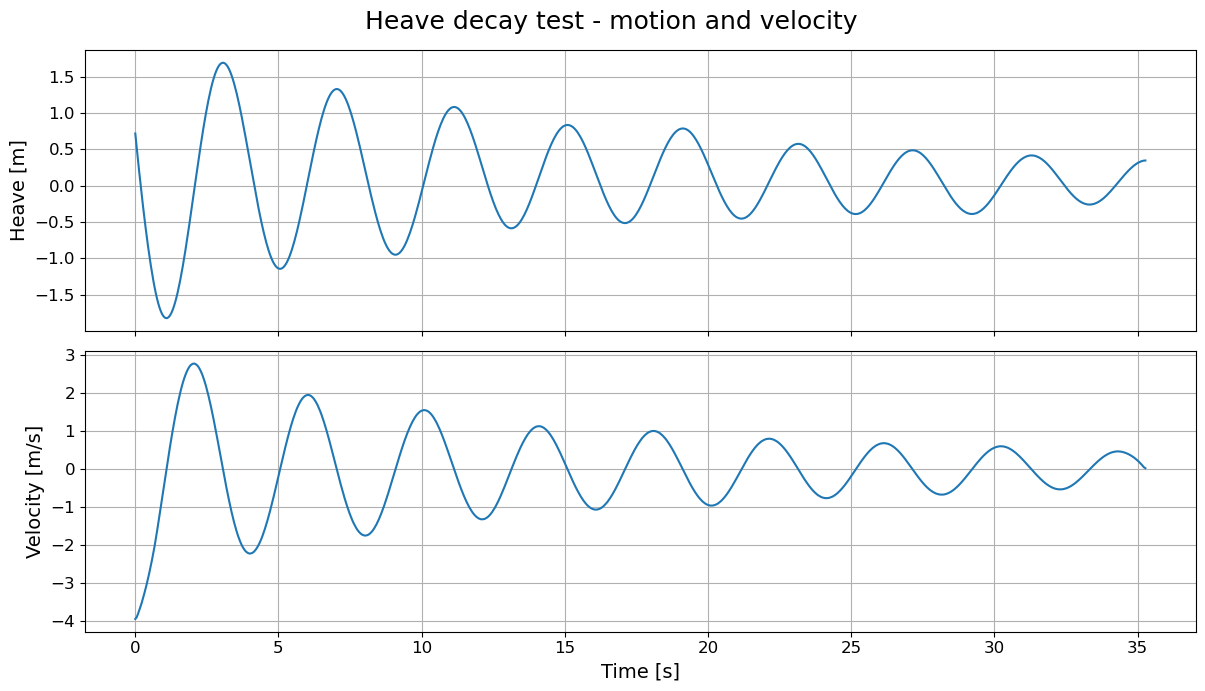

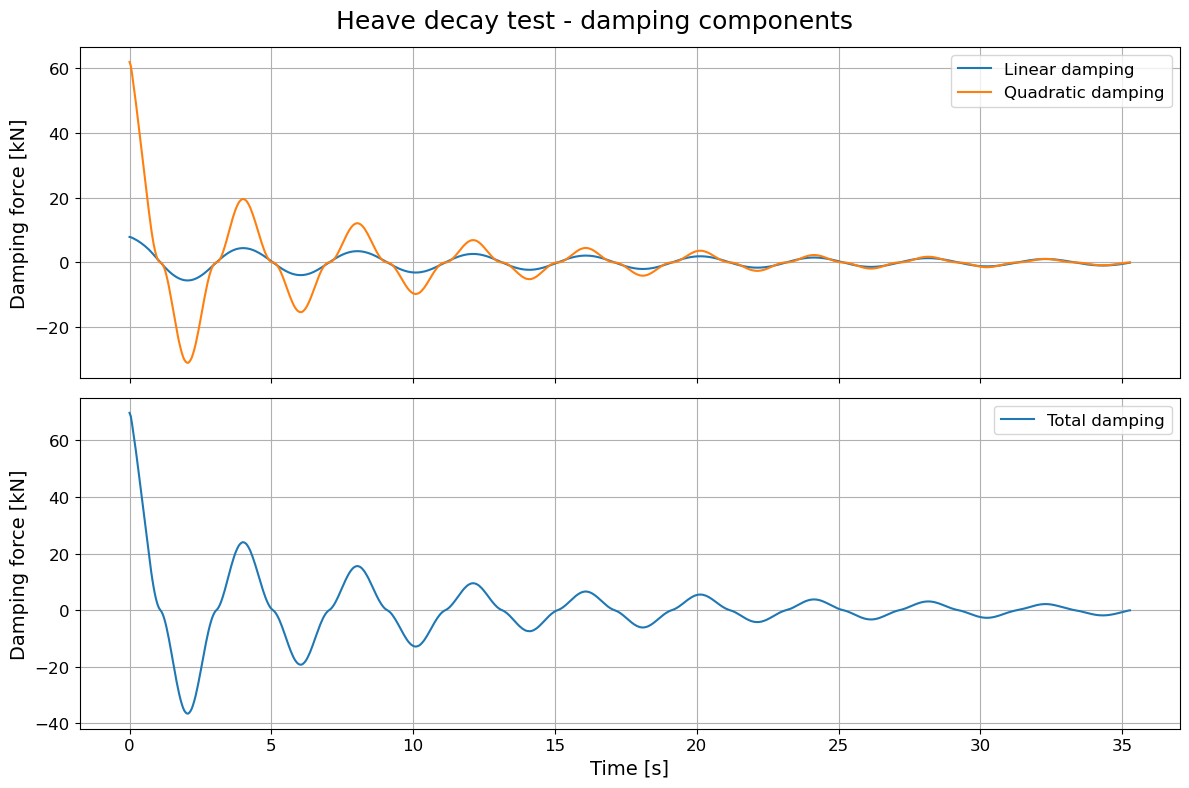

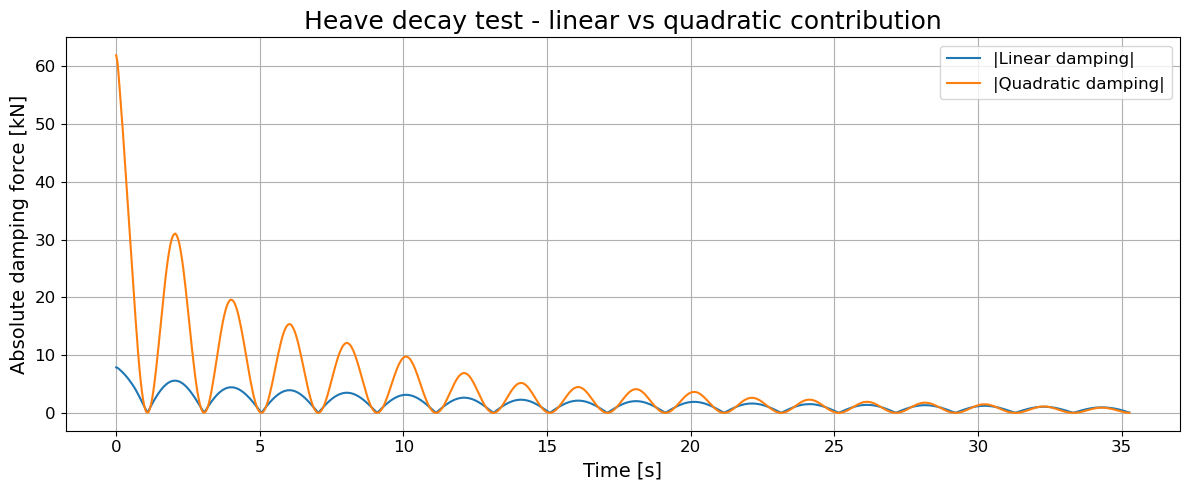

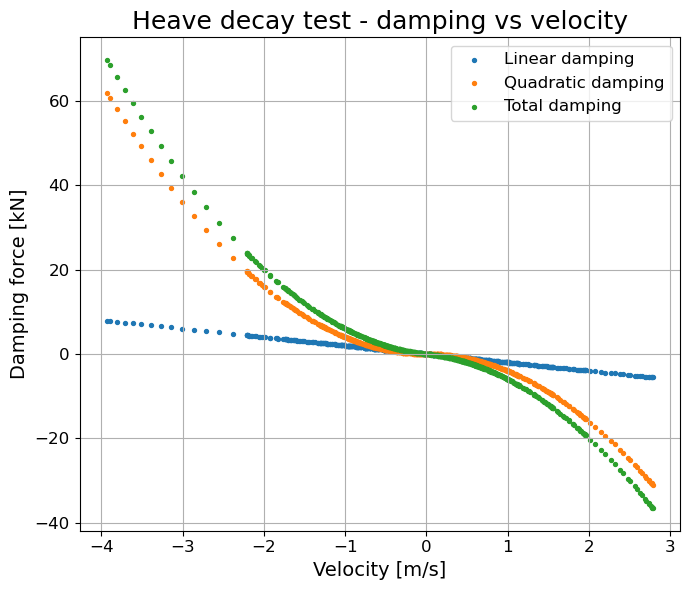


Processing roll decay test...


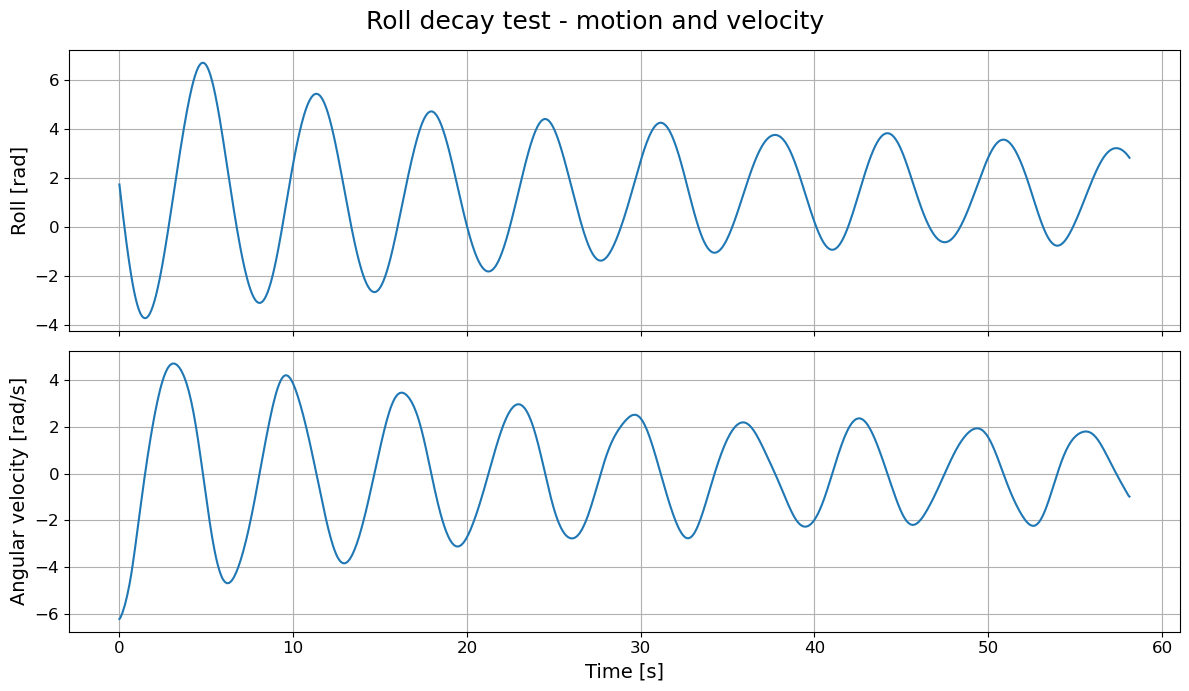

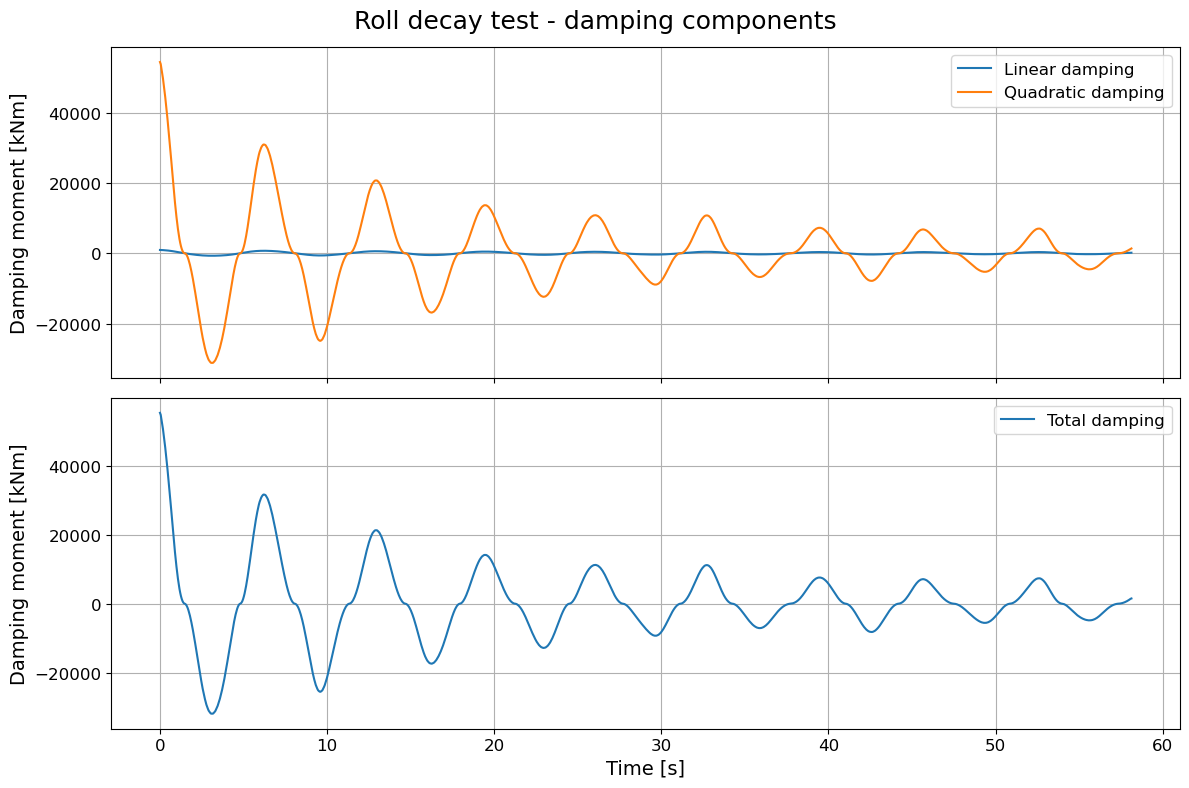

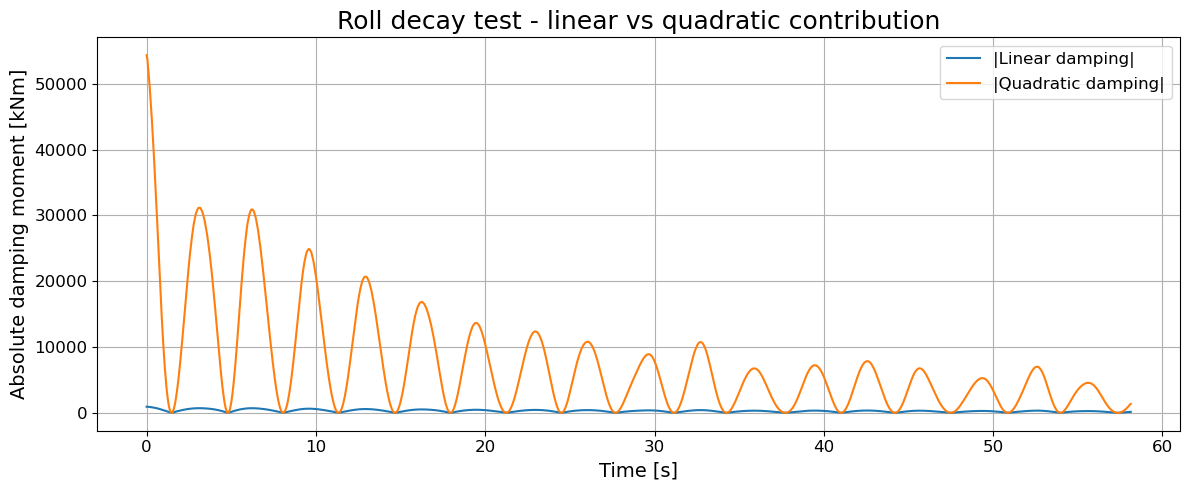

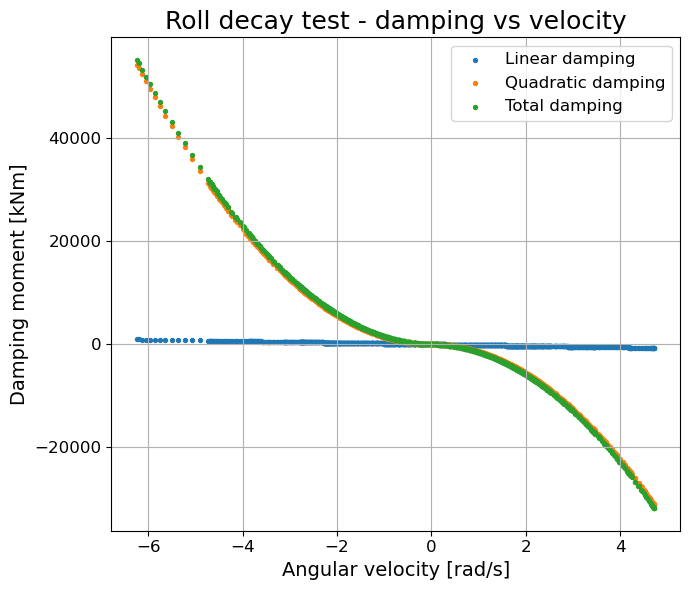


Processing pitch decay test...


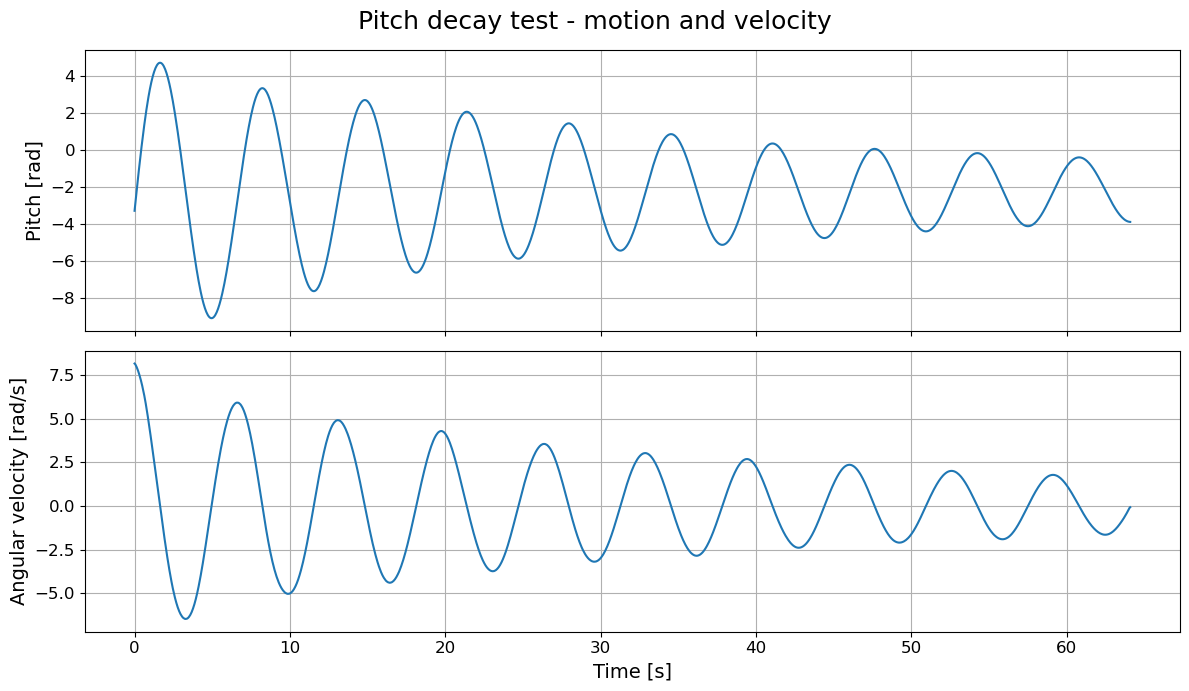

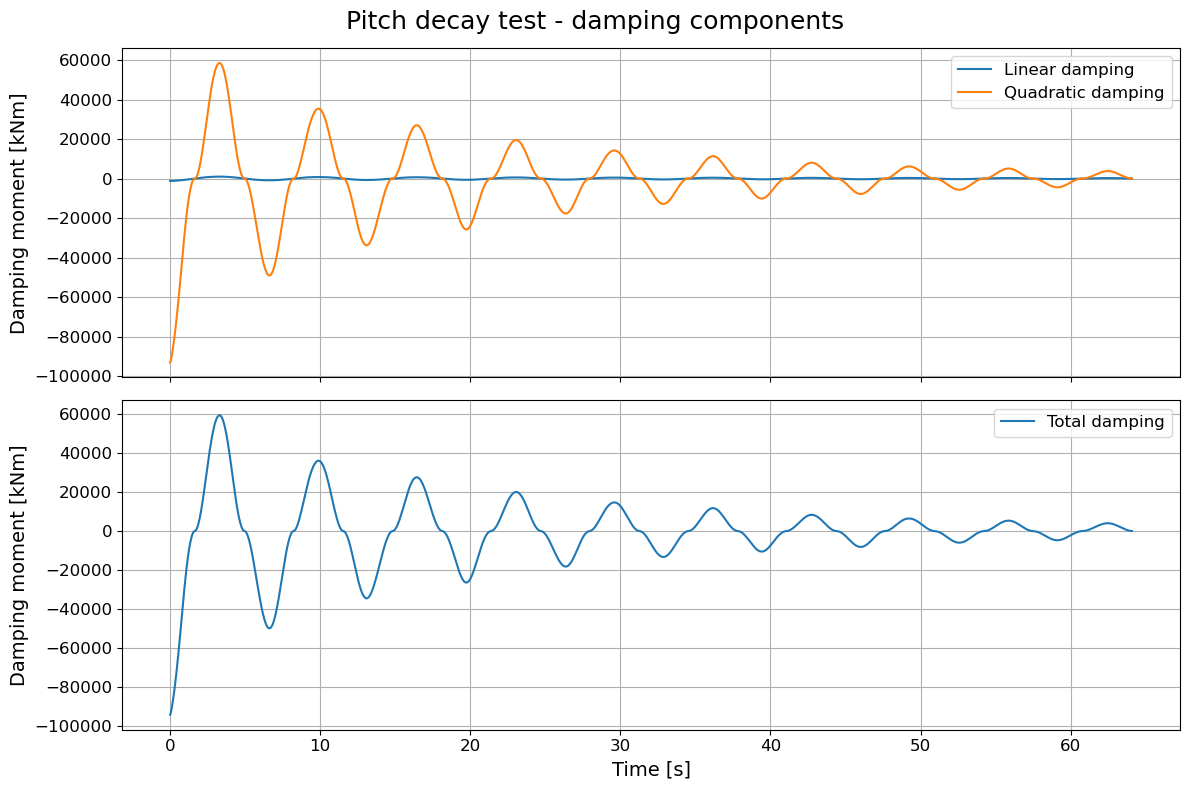

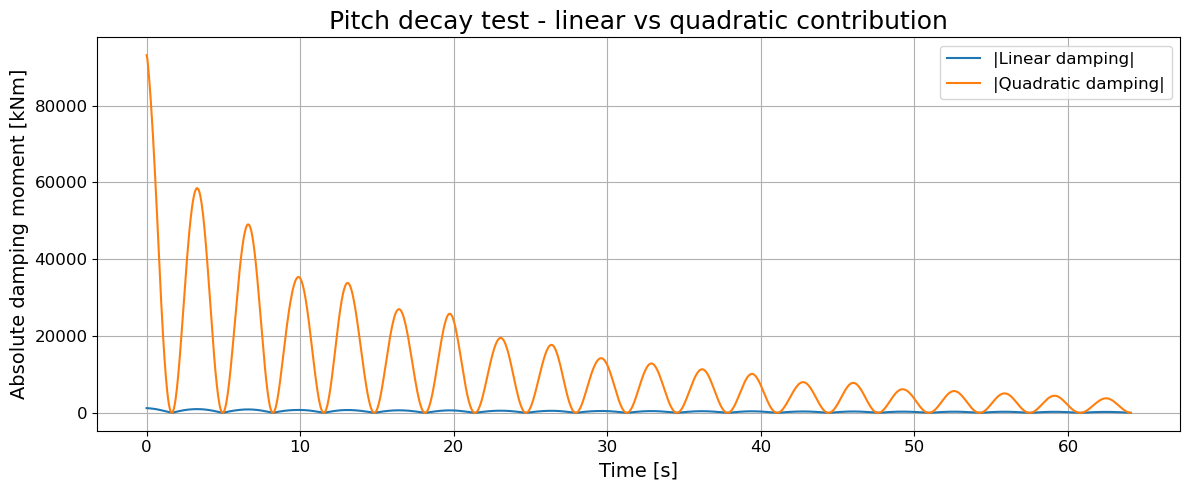

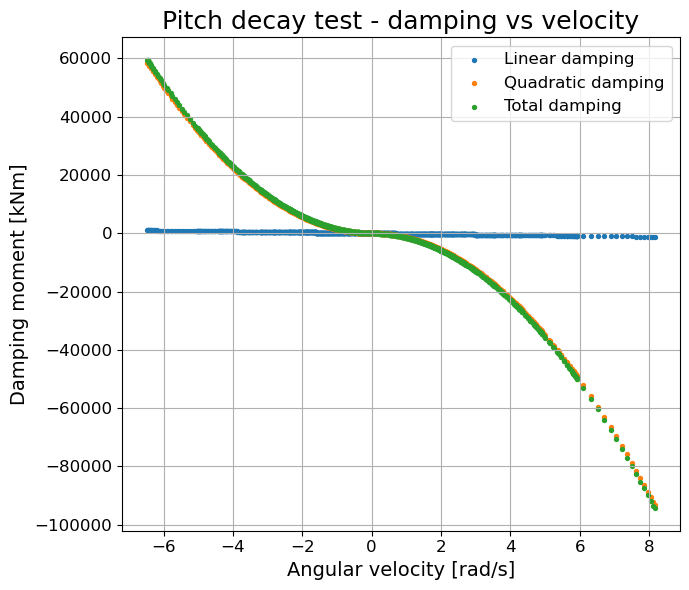


Summary damping contribution:


,DOF,velocity_RMS,velocity_max_abs,linear_RMS,linear_max_abs,quadratic_RMS,quadratic_max_abs,total_RMS,total_max_abs,quadratic_to_linear_RMS_ratio,linear_contribution_percentage,quadratic_contribution_percentage
0,heave,1.049796,3.934320,2.099591,7.868640,8.951715,61.915493,10.872089,69.784134,4.263551,18.998581,81.001427
1,roll,2.246969,6.230560,337.045288,934.583984,10739.132812,54347.828125,11054.686523,55282.414062,31.862581,3.042974,96.957024
2,pitch,2.719342,8.155504,407.901245,1223.325684,17142.085938,93117.148438,17519.949219,94340.476562,42.025089,2.324225,97.675781


In [15]:

# ============================================================
# INPUT
# ============================================================




# Instellingen voor snelheidsbepaling
use_savgol_filter = True
savgol_window = 31      # moet oneven zijn
savgol_polyorder = 3

# Output folder
output_folder = Path("damping_contribution_results_highquaddamping_fixed")
output_folder.mkdir(exist_ok=True)


# ============================================================
# FUNCTIES
# ============================================================

def load_h5m_signal(file_path, signal_name):
    """
    Laadt tijd en gefilterd motion-signaal uit een h5m bestand.
    """

    with h5py.File(file_path, "r") as f:
        t = f["CroppedSignals/time"][:]
        x = f[f"CroppedSignals/{signal_name}"][:]

    t = t - t[0]

    return t, x




def calculate_velocity(t, x):
    """
    Berekent snelheid met eventueel eerst een Savitzky-Golay filter.
    
    Heave:
        x [m]     -> v [m/s]

    Roll/pitch:
        x [rad]   -> v [rad/s]
    """

    if use_savgol_filter:
        window = savgol_window

        if window >= len(x):
            window = len(x) - 1

        if window % 2 == 0:
            window -= 1

        if window <= savgol_polyorder:
            raise ValueError("savgol_window moet groter zijn dan savgol_polyorder.")

        x_smooth = savgol_filter(
            x,
            window_length=window,
            polyorder=savgol_polyorder
        )
    else:
        x_smooth = x.copy()

    v = np.gradient(x_smooth, t)

    return v, x_smooth


def calculate_damping_components(v, B_lin, B_quad, damping_opposes_motion=True):
    """
    Berekent lineaire, kwadratische en totale dempingskracht/moment.

    Zonder minteken:
        F_lin   = B_lin * v
        F_quad  = B_quad * abs(v) * v

    Met minteken:
        F_lin   = -B_lin * v
        F_quad  = -B_quad * abs(v) * v

    Voor het vergelijken van de bijdrage maakt het teken niet uit,
    omdat de absolute waarden en RMS gebruikt worden.
    """

    sign = -1.0 if damping_opposes_motion else 1.0

    F_lin = sign * B_lin * v
    F_quad = sign * B_quad * np.abs(v) * v
    F_total = F_lin + F_quad

    return F_lin, F_quad, F_total


def rms(x):
    return np.sqrt(np.mean(x**2))


def make_summary(dof, v, F_lin, F_quad, F_total):
    """
    Maakt overzicht met snelheid, krachten/momenten en verhouding
    tussen kwadratische en lineaire demping.
    """

    lin_rms = rms(F_lin)
    quad_rms = rms(F_quad)

    if lin_rms == 0:
        ratio_quad_lin = np.nan
    else:
        ratio_quad_lin = quad_rms / lin_rms

    if lin_rms + quad_rms == 0:
        linear_percentage = np.nan
        quadratic_percentage = np.nan
    else:
        linear_percentage = 100 * lin_rms / (lin_rms + quad_rms)
        quadratic_percentage = 100 * quad_rms / (lin_rms + quad_rms)

    summary = {
        "DOF": dof,

        "velocity_RMS": rms(v),
        "velocity_max_abs": np.max(np.abs(v)),

        "linear_RMS": lin_rms,
        "linear_max_abs": np.max(np.abs(F_lin)),

        "quadratic_RMS": quad_rms,
        "quadratic_max_abs": np.max(np.abs(F_quad)),

        "total_RMS": rms(F_total),
        "total_max_abs": np.max(np.abs(F_total)),

        "quadratic_to_linear_RMS_ratio": ratio_quad_lin,
        "linear_contribution_percentage": linear_percentage,
        "quadratic_contribution_percentage": quadratic_percentage,
    }

    return summary


def apply_plot_style(ax):
    """
    Past standaard lettergroottes toe op een as.
    """
    ax.tick_params(axis="both", labelsize=TICK_SIZE)
    ax.xaxis.label.set_size(LABEL_SIZE)
    ax.yaxis.label.set_size(LABEL_SIZE)


def plot_motion_velocity(t, x, v, dof, output_folder):
    """
    Plot motion en snelheid.
    """

    if dof == "heave":
        motion_label = "Heave [m]"
        velocity_label = "Velocity [m/s]"
    else:
        motion_label = f"{dof.capitalize()} [rad]"
        velocity_label = "Angular velocity [rad/s]"

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    axes[0].plot(t, x)
    axes[0].set_ylabel(motion_label, fontsize=LABEL_SIZE)
    axes[0].grid(True)
    apply_plot_style(axes[0])

    axes[1].plot(t, v)
    axes[1].set_ylabel(velocity_label, fontsize=LABEL_SIZE)
    axes[1].set_xlabel("Time [s]", fontsize=LABEL_SIZE)
    axes[1].grid(True)
    apply_plot_style(axes[1])

    fig.suptitle(
        f"{dof.capitalize()} decay test - motion and velocity",
        fontsize=TITLE_SIZE
    )

    plt.tight_layout()

    save_path = output_folder / f"{dof}_motion_velocity.png"
    plt.savefig(save_path, dpi=300)
    plt.show()


def plot_damping_components(t, F_lin, F_quad, F_total, dof, output_folder):
    """
    Plot lineaire, kwadratische en totale demping.
    """

    if dof == "heave":
        ylabel = "Damping force [kN]"
    else:
        ylabel = "Damping moment [kNm]"

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    axes[0].plot(t, F_lin, label="Linear damping")
    axes[0].plot(t, F_quad, label="Quadratic damping")
    axes[0].set_ylabel(ylabel, fontsize=LABEL_SIZE)
    axes[0].grid(True)
    axes[0].legend(fontsize=TICK_SIZE)
    apply_plot_style(axes[0])

    axes[1].plot(t, F_total, label="Total damping")
    axes[1].set_ylabel(ylabel, fontsize=LABEL_SIZE)
    axes[1].set_xlabel("Time [s]", fontsize=LABEL_SIZE)
    axes[1].grid(True)
    axes[1].legend(fontsize=TICK_SIZE)
    apply_plot_style(axes[1])

    fig.suptitle(
        f"{dof.capitalize()} decay test - damping components",
        fontsize=TITLE_SIZE
    )

    plt.tight_layout()

    save_path = output_folder / f"{dof}_damping_components.png"
    plt.savefig(save_path, dpi=300)
    plt.show()


def plot_absolute_contribution(t, F_lin, F_quad, dof, output_folder):
    """
    Plot absolute bijdrage van lineaire en kwadratische demping.
    """

    if dof == "heave":
        ylabel = "Absolute damping force [kN]"
    else:
        ylabel = "Absolute damping moment [kNm]"

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(t, np.abs(F_lin), label="|Linear damping|")
    ax.plot(t, np.abs(F_quad), label="|Quadratic damping|")
    ax.set_xlabel("Time [s]", fontsize=LABEL_SIZE)
    ax.set_ylabel(ylabel, fontsize=LABEL_SIZE)
    ax.set_title(
        f"{dof.capitalize()} decay test - linear vs quadratic contribution",
        fontsize=TITLE_SIZE
    )
    ax.grid(True)
    ax.legend(fontsize=TICK_SIZE)
    apply_plot_style(ax)

    plt.tight_layout()

    save_path = output_folder / f"{dof}_linear_vs_quadratic_absolute.png"
    plt.savefig(save_path, dpi=300)
    plt.show()


def plot_force_velocity_relation(v, F_lin, F_quad, F_total, dof, output_folder):
    """
    Plot dempingskracht/moment als functie van snelheid.
    """

    if dof == "heave":
        xlabel = "Velocity [m/s]"
        ylabel = "Damping force [kN]"
    else:
        xlabel = "Angular velocity [rad/s]"
        ylabel = "Damping moment [kNm]"

    fig, ax = plt.subplots(figsize=(7, 6))

    ax.scatter(v, F_lin, s=8, label="Linear damping")
    ax.scatter(v, F_quad, s=8, label="Quadratic damping")
    ax.scatter(v, F_total, s=8, label="Total damping")
    ax.set_xlabel(xlabel, fontsize=LABEL_SIZE)
    ax.set_ylabel(ylabel, fontsize=LABEL_SIZE)
    ax.set_title(
        f"{dof.capitalize()} decay test - damping vs velocity",
        fontsize=TITLE_SIZE
    )
    ax.grid(True)
    ax.legend(fontsize=TICK_SIZE)
    apply_plot_style(ax)

    plt.tight_layout()

    save_path = output_folder / f"{dof}_damping_vs_velocity.png"
    plt.savefig(save_path, dpi=300)
    plt.show()

# ============================================================
# RUN ANALYSIS
# ============================================================

summary_rows = []

for dof, settings in decay_tests.items():

    print(f"\nProcessing {dof} decay test...")

    file_path = settings["path"]
    signal_name = settings["signal"]
    unit = settings["unit"]
    B_lin = settings["B_lin"]
    B_quad = settings["B_quad"]

    # Data laden
    t, x = load_h5m_signal(file_path, signal_name)

    # Unit conversie

    # Offset verwijderen
    x = x - np.mean(x[:100])

    # Snelheid bepalen
    v, x_smooth = calculate_velocity(t, x)

    # Dempingskracht of dempingsmoment berekenen
    F_lin, F_quad, F_total = calculate_damping_components(
        v,
        B_lin,
        B_quad,
        damping_opposes_motion=True
    )

    # Data per DOF opslaan
    result_df = pd.DataFrame({
        "time [s]": t,
        "motion": x_smooth,
        "velocity": v,
        "linear_damping": F_lin,
        "quadratic_damping": F_quad,
        "total_damping": F_total,
        "abs_linear_damping": np.abs(F_lin),
        "abs_quadratic_damping": np.abs(F_quad),
    })

    result_csv_path = output_folder / f"{dof}_damping_timeseries.csv"
    result_df.to_csv(result_csv_path, index=False)

    # Plots maken
    plot_motion_velocity(t, x_smooth, v, dof, output_folder)
    plot_damping_components(t, F_lin, F_quad, F_total, dof, output_folder)
    plot_absolute_contribution(t, F_lin, F_quad, dof, output_folder)
    plot_force_velocity_relation(v, F_lin, F_quad, F_total, dof, output_folder)

    # Samenvatting maken
    summary = make_summary(dof, v, F_lin, F_quad, F_total)
    summary_rows.append(summary)


summary_df = pd.DataFrame(summary_rows)

summary_csv_path = output_folder / "summary_damping_contribution.csv"
summary_df.to_csv(summary_csv_path, index=False)

print("\nSummary damping contribution:")
display(summary_df)